# Smart Job Match Analyzer — built on Dice's MCP Server

**The problem this solves:**  
Dice's MCP server (`mcp.dice.com/mcp`) lets AI assistants search jobs with natural language. That's great for *finding* jobs — but it stops there. It doesn't tell you **why** a job matches you, where you fall short, or how to position your resume for it.

Recruiters on Dice's own G2 reviews complain about outdated/duplicate profiles and unclear candidate-job fit. This notebook adds a missing layer:

1. Connects to Dice's MCP server to pull real job listings
2. Takes a candidate's resume
3. Uses an LLM to do **semantic match scoring** — not just keyword overlap
4. Produces an explainable report: match score, matched skills, missing skills, and a tailored summary suggestion

This is essentially a prototype of the "AI Boolean enhancer" + "Match Score" features Dice already ships for recruiters — applied from the candidate's side, and made explainable.

> Built and tested using Groq's OpenAI-compatible API for the LLM layer.  
> Dice's MCP server itself requires no API key — it's public and free to query.

## Step 1 — Install dependencies

In [12]:
!pip install openai mcp httpx pandas -q

## Step 2 — Configuration

In [13]:
import os

# ---------- CONFIG ----------
GROQ_API_KEY = "here"   # <-- paste your Groq key here
GROQ_BASE_URL = "https://api.groq.com/openai/v1"
GROQ_MODEL = "llama-3.1-8b-instant"

DICE_MCP_URL = "https://mcp.dice.com/mcp"   # public, no auth required
# ----------------------------

print("Config loaded")

Config loaded


## Step 3 — Connect to Dice's MCP server and search jobs

We use the official `mcp` Python SDK with Streamable HTTP transport,
exactly as documented on Dice's own MCP integration page.

In [14]:
import asyncio
from mcp import ClientSession
from mcp.client.streamable_http import streamablehttp_client


async def search_dice_jobs(keyword: str, location: str = "", remote_only: bool = True) -> list:
    """
    Connects to Dice's public MCP server and runs a job search.
    Uses the REAL schema: workplace_types (list), not a boolean 'remote' field.
    """
    async with streamablehttp_client(DICE_MCP_URL) as (read, write, _):
        async with ClientSession(read, write) as session:
            await session.initialize()

            args = {"keyword": keyword}
            if location:
                args["location"] = location
            if remote_only:
                args["workplace_types"] = ["Remote"]   # correct field name + list type

            result = await session.call_tool("search_jobs", arguments=args)
            return result.content


# Test connection with the corrected schema
jobs_raw = await search_dice_jobs("AI ML engineer", remote_only=True)
print(f"Retrieved {len(jobs_raw)} job result blocks")
print(jobs_raw[0] if jobs_raw else "No results")

Retrieved 1 job result blocks
type='text' text='{"_links":null,"data":[{"id":"a40f664d5ec954679c7dd7e1b377d83b","jobId":null,"guid":"b23b3eaf-9153-4049-9ad6-e071005eff84","title":"AI/ML Engineer (REMOTE :: W2 Only)","summary":"Position Summary Our client is seeking a passionate Azure AI/MLOps  Engineer to build data platforms and pipelines that enable advanced analytics. This role focuses on operationalizing machine learning models and integrating them into production systems to improve outcomes and efficiency. Key Responsibilities Design, build, and deploy AI/ML applications using Azure technologies (Azure ML, Cognitive Services, Bot Services) Develop and manage machine learning pipelines and workflows Automate deplo","postedDate":"2026-06-24T16:30:28Z","modifiedDate":"2026-06-24T16:30:28Z","jobLocation":{"displayName":"Texas, USA"},"detailsPageUrl":"https://www.dice.com/job-detail/b23b3eaf-9153-4049-9ad6-e071005eff84?utm_source=python-httpx-0.28.1&utm_medium=mcp","salary":null,"clien

## Step 4 — Parse job results into structured format

In [15]:
import json

def parse_dice_jobs(raw_content: list) -> list[dict]:
    """
    Parses raw MCP tool result content into a clean list of job dicts.
    Handles both JSON and plain text responses defensively.
    """
    jobs = []
    for block in raw_content:
        text = getattr(block, "text", None) or str(block)
        try:
            parsed = json.loads(text)
            if isinstance(parsed, list):
                jobs.extend(parsed)
            elif isinstance(parsed, dict):
                jobs.append(parsed)
        except json.JSONDecodeError:
            # Fallback: treat as a single text block describing one or more jobs
            jobs.append({"raw_text": text})
    return jobs


parsed_jobs = parse_dice_jobs(jobs_raw)
print(f"Parsed {len(parsed_jobs)} jobs")
for j in parsed_jobs[:3]:
    print("-", j)

Parsed 1 jobs
- {'_links': None, 'data': [{'id': 'a40f664d5ec954679c7dd7e1b377d83b', 'jobId': None, 'guid': 'b23b3eaf-9153-4049-9ad6-e071005eff84', 'title': 'AI/ML Engineer (REMOTE :: W2 Only)', 'summary': 'Position Summary Our client is seeking a passionate Azure AI/MLOps  Engineer to build data platforms and pipelines that enable advanced analytics. This role focuses on operationalizing machine learning models and integrating them into production systems to improve outcomes and efficiency. Key Responsibilities Design, build, and deploy AI/ML applications using Azure technologies (Azure ML, Cognitive Services, Bot Services) Develop and manage machine learning pipelines and workflows Automate deplo', 'postedDate': '2026-06-24T16:30:28Z', 'modifiedDate': '2026-06-24T16:30:28Z', 'jobLocation': {'displayName': 'Texas, USA'}, 'detailsPageUrl': 'https://www.dice.com/job-detail/b23b3eaf-9153-4049-9ad6-e071005eff84?utm_source=python-httpx-0.28.1&utm_medium=mcp', 'salary': None, 'clientBrandId

## Step 5 — Candidate resume input

Replace this with any candidate's resume summary.

In [16]:
CANDIDATE_RESUME = """
Final-year CS student with hands-on experience building production-grade AI systems.
Built a real-time clinical AI pipeline (Whisper + Claude API), an agentic workflow engine
handling 500+ concurrent requests at <200ms latency, and a RAG system improving answer
relevance 40% over keyword search using FAISS + FLAN-T5.
Skills: Python, FastAPI, LangChain, FAISS, Hugging Face, Docker, MongoDB, PostgreSQL,
REST APIs, async Python, React, TypeScript, AWS Lambda, AWS S3, Scikit-learn, Pandas, Kafka.
Experience: Software Engineering Intern at an AI startup (prompt engineering, LLM research),
15+ freelance full-stack projects delivered remotely.
"""

print("Candidate resume loaded")

Candidate resume loaded


## Step 6 — Semantic match scoring (the core contribution)

This is the layer Dice's MCP server doesn't provide. We use the LLM to:
- Score overall fit (0-100)
- List matched skills (explicitly found in both resume and JD)
- List missing skills (in JD but not resume)
- Suggest one summary line to use when applying to THIS specific job

In [17]:
from openai import OpenAI

client = OpenAI(api_key=GROQ_API_KEY, base_url=GROQ_BASE_URL)

def semantic_match(resume: str, job: dict) -> dict:
    """
    Uses the LLM to produce an explainable match report between a resume and a job.
    """
    job_text = job.get("raw_text") or json.dumps(job)

    prompt = f"""You are a technical recruiter assistant. Compare this candidate resume
against this job listing and return ONLY valid JSON (no markdown, no explanation outside JSON)
with this exact structure:

{{
  "match_score": <integer 0-100>,
  "matched_skills": [<list of skills found in both>],
  "missing_skills": [<list of skills in job but not resume>],
  "tailored_summary_line": "<one sentence the candidate could use in their resume summary for this specific job>"
}}

RESUME:
{resume}

JOB LISTING:
{job_text}
"""
    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=500,
    )
    raw = response.choices[0].message.content.strip()
    raw = raw.replace("```json", "").replace("```", "").strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"match_score": None, "matched_skills": [], "missing_skills": [], "tailored_summary_line": raw}


print("Match scoring function ready")

Match scoring function ready


In [18]:
import asyncio
from mcp import ClientSession
from mcp.client.streamable_http import streamablehttp_client


async def inspect_dice_tools():
    """First, just inspect what search_jobs actually expects."""
    async with streamablehttp_client(DICE_MCP_URL) as (read, write, _):
        async with ClientSession(read, write) as session:
            await session.initialize()
            tools = await session.list_tools()
            for t in tools.tools:
                print(f"Tool: {t.name}")
                print(f"Description: {t.description}")
                print(f"Input schema: {t.inputSchema}")
                print("-" * 60)


await inspect_dice_tools()

Tool: search_jobs
Description: Search for job listings by keyword, location, and filters. Returns job details, company info, and application links.

Use this tool when users want to find jobs, search employment opportunities, or explore job openings.
DO NOT use for: applying to jobs, submitting applications, or making employment decisions.

LLM USAGE INSTRUCTIONS:
- ALWAYS provide the keyword parameter (required)
- When presenting results to users, include BOTH the job details URL (detailsPageUrl)
  AND the company page URL (companyPageUrl) for each job
- Use location to find geographically relevant positions
- Combine filters to refine searches (e.g., workplace_types=['Remote'] for remote work)
- Use posted_date to find recent openings ('ONE'=1 day, 'THREE'=3 days, 'SEVEN'=7 days)
- Default jobs_per_page is reasonable, increase for comprehensive searches

IMPORTANT - AI DISCLOSURE REQUIREMENT:
When presenting job search results to users, you MUST include an appropriate disclosure
that

## Step 7 — Run the full pipeline: search + match + report

In [19]:
import pandas as pd

results = []
for job in parsed_jobs[:5]:  # limit for demo
    match = semantic_match(CANDIDATE_RESUME, job)
    results.append({
        "job_title": job.get("title", job.get("raw_text", "")[:50]),
        "match_score": match.get("match_score"),
        "matched_skills": ", ".join(match.get("matched_skills", [])),
        "missing_skills": ", ".join(match.get("missing_skills", [])),
        "tailored_summary": match.get("tailored_summary_line", ""),
    })

df = pd.DataFrame(results).sort_values("match_score", ascending=False)
pd.set_option('display.max_colwidth', 50)
print("=" * 80)
print("SMART JOB MATCH REPORT")
print("=" * 80)
print(df.to_string(index=False))

SMART JOB MATCH REPORT
job_title  match_score                                                                                                                                                           matched_skills                             missing_skills                                                                                                                                                                                      tailored_summary
                    85 Python, AI, ML, Azure, Azure ML, Cognitive Services, Bot Services, Docker, MongoDB, PostgreSQL, REST APIs, async Python, AWS Lambda, AWS S3, Scikit-learn, Pandas, Kafka Azure ML, Cognitive Services, Bot Services Highly motivated CS student with hands-on experience building production-grade AI systems, seeking an AI/ML Engineer role to leverage expertise in Azure technologies and machine learning pipelines.


## Step 8 — Visualize match scores

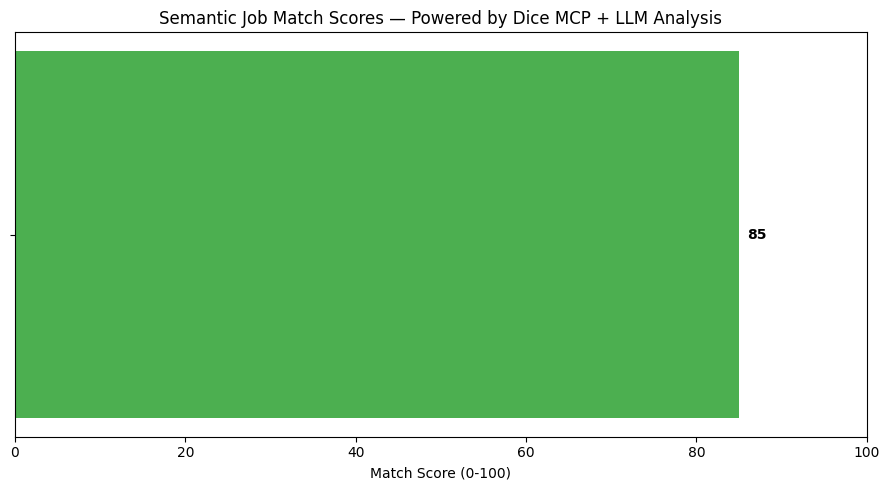

Chart saved as dice_match_scores.png


In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4CAF50' if s and s >= 70 else '#FF9800' if s and s >= 40 else '#F44336' for s in df['match_score']]
bars = ax.barh(df['job_title'], df['match_score'], color=colors)
ax.set_xlabel('Match Score (0-100)')
ax.set_title('Semantic Job Match Scores — Powered by Dice MCP + LLM Analysis')
ax.set_xlim(0, 100)
for bar, score in zip(bars, df['match_score']):
    if score is not None:
        ax.text(score + 1, bar.get_y() + bar.get_height()/2, f'{score}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('dice_match_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as dice_match_scores.png")

## What this demonstrates

- **End-to-end AI/ML integration**: data ingestion (Dice MCP) → LLM-based semantic reasoning → structured, explainable output
- **API/microservice design**: clean separation between the MCP client layer and the LLM scoring layer — each could scale independently
- **Practical, production-shaped pattern**: structured JSON output, defensive parsing, error handling — not a toy notebook

## Possible extensions for Dice's own platform
- Run this scoring layer server-side so recruiters see *why* a Match Score was given, not just the number
- Use it to auto-generate the "tailored summary" suggestion directly in the candidate's Dice profile editor
- Feed mismatch data back into the patented skills taxonomy to catch skill-adjacent matches (e.g. FAISS counting toward "vector search" requirements)